# 01 — Exploratory Data Analysis (M5 Dataset)

**Project:** smart-inventory-forecaster  
**Dataset:** M5 Accuracy Competition — Walmart hierarchical sales, 2011-01-29 → 2016-06-19  
**Goal:** Understand data shape, volume distribution, time-series patterns, sparsity, and calendar effects before building any forecasting models.  

All file I/O goes through `src.data.loader`. Intermediate DataFrames are cached to `data/processed/` as Parquet.

In [8]:
import sys
from pathlib import Path

# notebooks/ is one level below project root
_here = Path.cwd()
ROOT = _here.parent if _here.name == "notebooks" else _here
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"Project root : {ROOT}")
print(f"Processed dir: {PROCESSED}")

Project root : C:\Users\UCWAcc\projects\smart-inventory-forecaster
Processed dir: C:\Users\UCWAcc\projects\smart-inventory-forecaster\data\processed


## 1  Setup & Data Shape

Load all three M5 files and inspect their structure.  
We're looking for: row/column counts, dtype breakdown, memory footprint, and the date range covered by the calendar.

In [9]:
from src.data.loader import load_sales, load_calendar, load_prices

sales_wide = load_sales()   # full wide-format file, ~30 k rows
cal        = load_calendar()
prices     = load_prices()

for name, df in [
    ("sales_train_evaluation", sales_wide),
    ("calendar",               cal),
    ("sell_prices",            prices),
]:
    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    print(f"\n{'─' * 55}")
    print(f"  {name}")
    print(f"  Shape  : {df.shape[0]:,} rows x {df.shape[1]:,} cols")
    print(f"  Memory : {mem_mb:.1f} MB")
    print(f"  Dtypes : {df.dtypes.value_counts().to_dict()}")

day_cols = [c for c in sales_wide.columns if c.startswith("d_")]
print(f"\nCalendar range : {cal['date'].min().date()}  to  {cal['date'].max().date()}")
print(f"Total days     : {len(cal)}")
print(f"Day columns    : {day_cols[0]} to {day_cols[-1]}  ({len(day_cols)} days)")
print(f"Metadata cols  : {[c for c in sales_wide.columns if not c.startswith('d_')]}")


───────────────────────────────────────────────────────
  sales_train_evaluation
  Shape  : 30,490 rows x 1,947 cols
  Memory : 476.8 MB
  Dtypes : {dtype('int64'): 1941, <StringDtype(na_value=nan)>: 6}

───────────────────────────────────────────────────────
  calendar
  Shape  : 1,969 rows x 14 cols
  Memory : 0.2 MB
  Dtypes : {dtype('int64'): 7, <StringDtype(na_value=nan)>: 6, dtype('<M8[us]'): 1}

───────────────────────────────────────────────────────
  sell_prices
  Shape  : 6,841,121 rows x 4 cols
  Memory : 333.6 MB
  Dtypes : {<StringDtype(na_value=nan)>: 2, dtype('int64'): 1, dtype('float64'): 1}

Calendar range : 2011-01-29  to  2016-06-19
Total days     : 1969
Day columns    : d_1 to d_1941  (1941 days)
Metadata cols  : ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']


## 2  Volume Landscape

How is the data distributed across Walmart's product/store taxonomy?  
We compute total units sold per SKU-store (sum across all day columns) and aggregate at four levels: **category, department, store, state**.  
This answers "what is this dataset actually made of?" before we look at anything time-based.

C:\Users\UCWAcc\AppData\Local\Temp\ipykernel_8372\1587542864.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sales_wide["total_sales"] = sales_wide[day_cols].sum(axis=1)


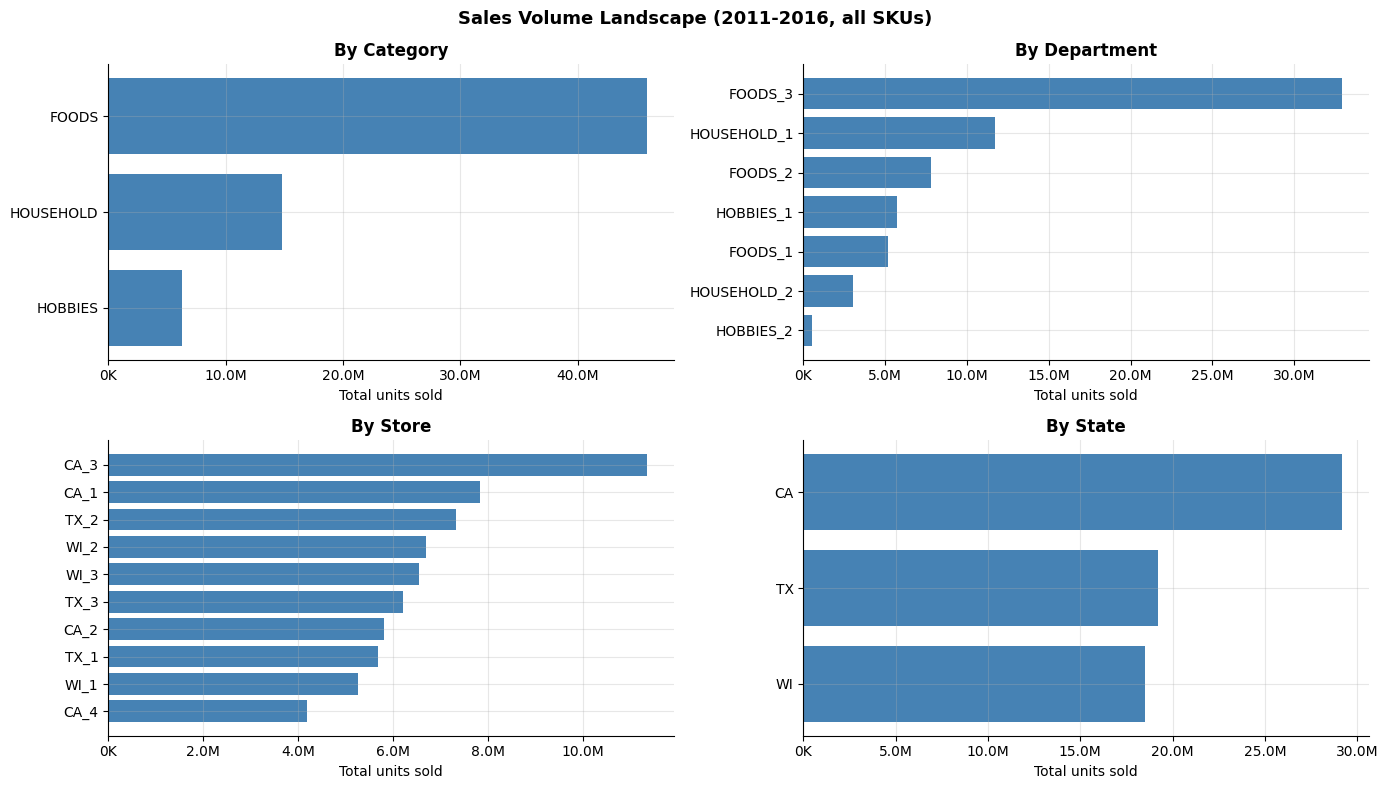

Total SKU-store rows : 30,490
Unique item_ids      : 3,049
Unique stores        : 10
Unique categories    : 3
Unique departments   : 7


In [10]:
sales_wide["total_sales"] = sales_wide[day_cols].sum(axis=1)

def bar_h(ax, series, title, xlabel="Total units sold"):
    series = series.sort_values()
    ax.barh(series.index, series.values, color="steelblue")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
    )

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Sales Volume Landscape (2011-2016, all SKUs)", fontsize=13, fontweight="bold")

bar_h(axes[0, 0], sales_wide.groupby("cat_id")["total_sales"].sum(),  "By Category")
bar_h(axes[0, 1], sales_wide.groupby("dept_id")["total_sales"].sum(), "By Department")
bar_h(axes[1, 0], sales_wide.groupby("store_id")["total_sales"].sum(), "By Store")
bar_h(axes[1, 1], sales_wide.groupby("state_id")["total_sales"].sum(), "By State")

plt.tight_layout()
plt.savefig(PROCESSED / "fig_volume_landscape.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Total SKU-store rows : {len(sales_wide):,}")
print(f"Unique item_ids      : {sales_wide['item_id'].nunique():,}")
print(f"Unique stores        : {sales_wide['store_id'].nunique():,}")
print(f"Unique categories    : {sales_wide['cat_id'].nunique():,}")
print(f"Unique departments   : {sales_wide['dept_id'].nunique():,}")

## 3  Time Series at Different Aggregation Levels

**Sampling rationale:** Melting the full 30 k-row wide file to long format would produce ~58 M rows, which is multi-GB in memory. Instead we work on **store CA_1** (one of Walmart's California stores, ~3 000 SKUs). This gives a representative ~5.9 M-row long frame that stays comfortable in memory and is the natural unit for a store-level forecasting system.

We melt, join the calendar for real dates, then plot at three levels:
1. Total daily sales across all CA_1 SKUs — reveals trend and yearly seasonality.
2. Daily sales by category — shows which categories drive the signal.
3. Average sales by day of week — quantifies the weekly seasonal cycle.

In [11]:
STORE = "CA_1"
META_COLS = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

sample_wide = sales_wide[sales_wide["store_id"] == STORE][META_COLS + day_cols].copy()
print(f"Sample: {len(sample_wide):,} SKUs in {STORE}")

sample_long = sample_wide.melt(
    id_vars=META_COLS,
    value_vars=day_cols,
    var_name="d",
    value_name="sales",
)
print(f"Long format: {len(sample_long):,} rows")

cal_slim = cal[["d", "date", "weekday", "wday", "month", "year",
                "event_name_1", "event_type_1",
                "snap_CA", "snap_TX", "snap_WI"]].copy()
sample_long = sample_long.merge(cal_slim, on="d", how="left")
sample_long["date"] = pd.to_datetime(sample_long["date"])

print(f"Date range: {sample_long['date'].min().date()} to {sample_long['date'].max().date()}")

sample_long.to_parquet(PROCESSED / "eda_sample_long_CA1.parquet", index=False)
print("Saved -> data/processed/eda_sample_long_CA1.parquet")

Sample: 3,049 SKUs in CA_1
Long format: 5,918,109 rows
Date range: 2011-01-29 to 2016-05-22
Saved -> data/processed/eda_sample_long_CA1.parquet


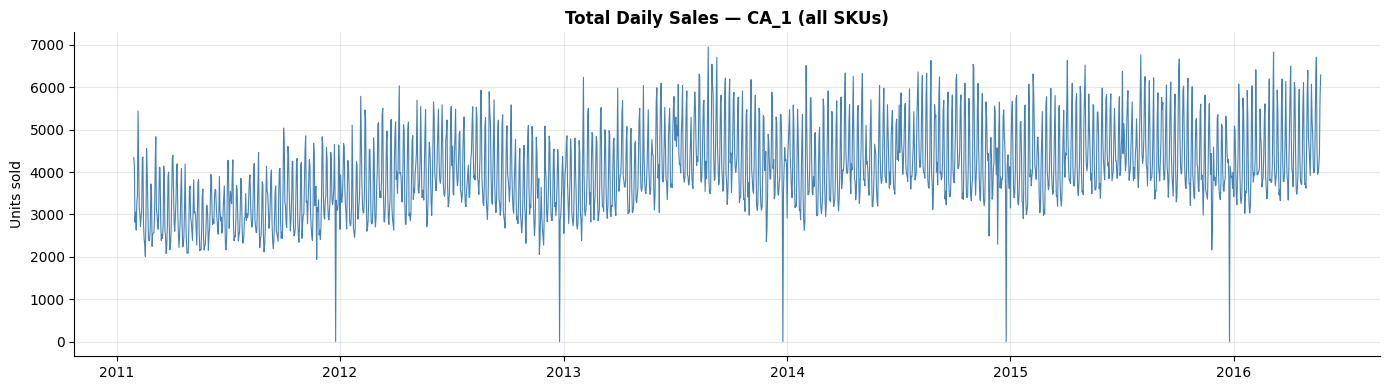

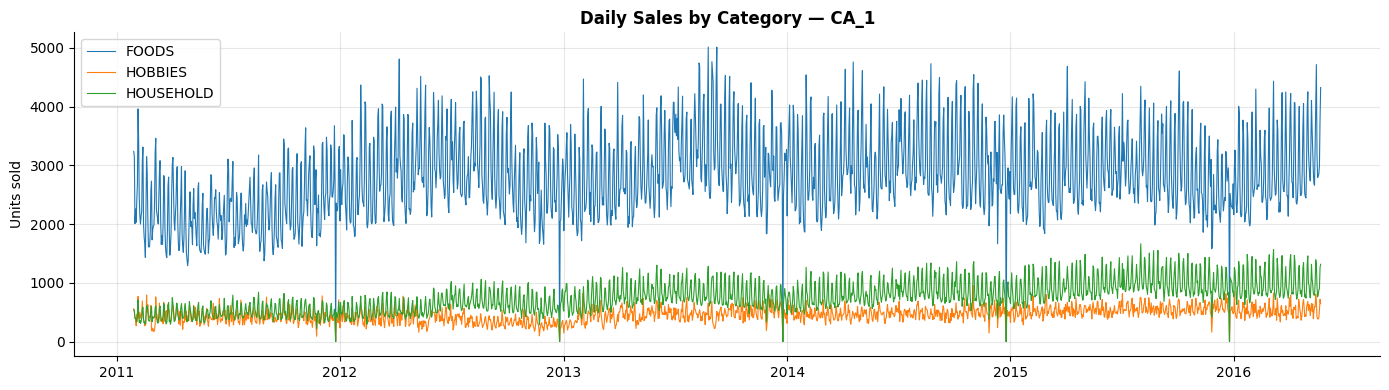

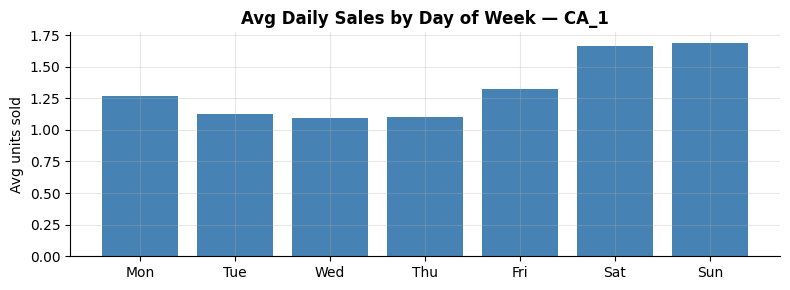

In [12]:
# ── 1. Total daily sales ──────────────────────────────────────────────────────
daily = sample_long.groupby("date")["sales"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, linewidth=0.8, color="steelblue")
ax.set_title(f"Total Daily Sales — {STORE} (all SKUs)", fontweight="bold")
ax.set_ylabel("Units sold")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(PROCESSED / "fig_ts_total_CA1.png", dpi=100, bbox_inches="tight")
plt.show()

# ── 2. By category ────────────────────────────────────────────────────────────
daily_cat = sample_long.groupby(["date", "cat_id"])["sales"].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 4))
for cat in daily_cat.columns:
    ax.plot(daily_cat.index, daily_cat[cat], linewidth=0.8, label=cat)
ax.set_title(f"Daily Sales by Category — {STORE}", fontweight="bold")
ax.set_ylabel("Units sold")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(PROCESSED / "fig_ts_by_category_CA1.png", dpi=100, bbox_inches="tight")
plt.show()

# ── 3. Weekly seasonality ─────────────────────────────────────────────────────
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_avg = sample_long.groupby("weekday")["sales"].mean().reindex(DAY_ORDER)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(dow_avg)), dow_avg.values, color="steelblue")
ax.set_xticks(range(len(dow_avg)))
ax.set_xticklabels([d[:3] for d in DAY_ORDER])
ax.set_title(f"Avg Daily Sales by Day of Week — {STORE}", fontweight="bold")
ax.set_ylabel("Avg units sold")
plt.tight_layout()
plt.savefig(PROCESSED / "fig_dow_CA1.png", dpi=100, bbox_inches="tight")
plt.show()

## 4  Sparsity & Demand Intermittency

Not all SKUs are SARIMA-suitable. A SKU with 70 %+ zero-sales days is **intermittent** — its demand is sporadic and lumpy, better handled by Croston's method or a bootstrap approach. A SKU with consistent non-zero demand is **continuous** — a good fit for SARIMA, Prophet, or XGBoost.

We quantify sparsity across all 30 k SKU-store rows (no melt needed — wide format is efficient here):
- **Zero-rate per SKU**: fraction of the 1 941 days with zero sales.
- **Mean daily sales per SKU**: overall demand-volume distribution.

sku_metrics shape: (30490, 9)


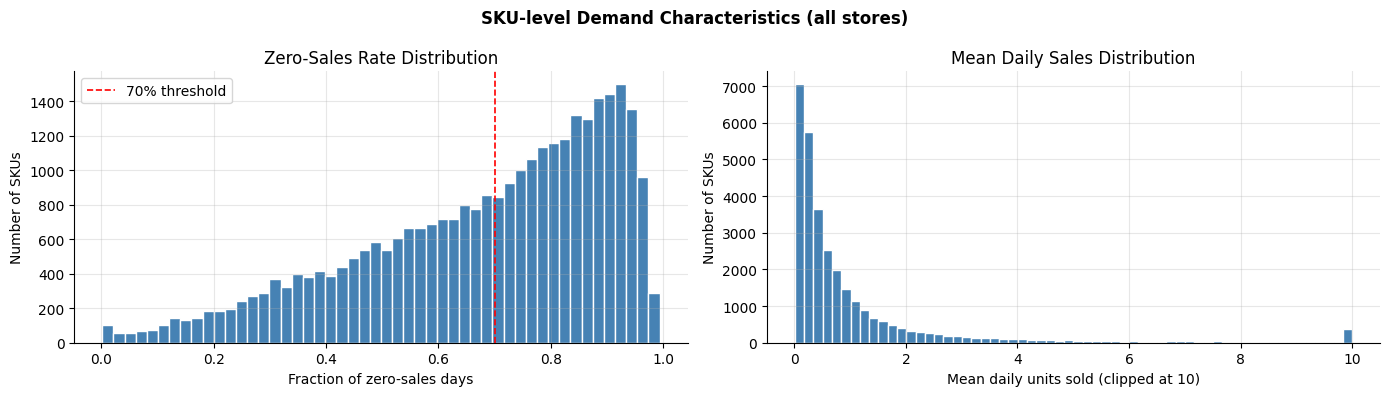

Intermittent SKUs (>=70% zero days): 16,724  (54.9%)
Continuous SKUs   (<70% zero days) : 13,766  (45.1%)

Mean zero-rate by category:
cat_id
HOBBIES      0.771492
HOUSEHOLD    0.716022
FOODS        0.617734


In [13]:
sku_metrics = pd.DataFrame({
    "id":          sales_wide["id"].values,
    "item_id":     sales_wide["item_id"].values,
    "cat_id":      sales_wide["cat_id"].values,
    "dept_id":     sales_wide["dept_id"].values,
    "store_id":    sales_wide["store_id"].values,
    "total_sales": sales_wide[day_cols].sum(axis=1).values,
    "zero_days":   (sales_wide[day_cols] == 0).sum(axis=1).values,
    "mean_daily":  sales_wide[day_cols].mean(axis=1).values,
})
sku_metrics["zero_rate"] = sku_metrics["zero_days"] / len(day_cols)

sku_metrics.to_parquet(PROCESSED / "eda_sku_metrics.parquet", index=False)
print(f"sku_metrics shape: {sku_metrics.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("SKU-level Demand Characteristics (all stores)", fontweight="bold")

axes[0].hist(sku_metrics["zero_rate"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0.7, color="red", linestyle="--", linewidth=1.2, label="70% threshold")
axes[0].set_xlabel("Fraction of zero-sales days")
axes[0].set_ylabel("Number of SKUs")
axes[0].set_title("Zero-Sales Rate Distribution")
axes[0].legend()

axes[1].hist(sku_metrics["mean_daily"].clip(upper=10), bins=60, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Mean daily units sold (clipped at 10)")
axes[1].set_ylabel("Number of SKUs")
axes[1].set_title("Mean Daily Sales Distribution")

plt.tight_layout()
plt.savefig(PROCESSED / "fig_sparsity.png", dpi=100, bbox_inches="tight")
plt.show()

n = len(sku_metrics)
intermittent = (sku_metrics["zero_rate"] >= 0.7).sum()
continuous   = n - intermittent
print(f"Intermittent SKUs (>=70% zero days): {intermittent:,}  ({intermittent/n:.1%})")
print(f"Continuous SKUs   (<70% zero days) : {continuous:,}  ({continuous/n:.1%})")
print("\nMean zero-rate by category:")
print(sku_metrics.groupby("cat_id")["zero_rate"].mean().sort_values(ascending=False).to_string())

## 5  Event & SNAP Effects

M5 includes two rich calendar signals:
- **Named events** (e.g., SuperBowl, Christmas, Mother's Day) — captured in `event_name_1`.
- **SNAP days** — days when food-stamp recipients can use benefits; particularly relevant for the FOODS category.

We look at three questions using the CA_1 long-format sample:
1. Do event days lift average sales vs. non-event days?
2. Do SNAP days lift FOODS sales specifically?
3. What does the Christmas sales window look like (3 weeks before/after Dec 25)?

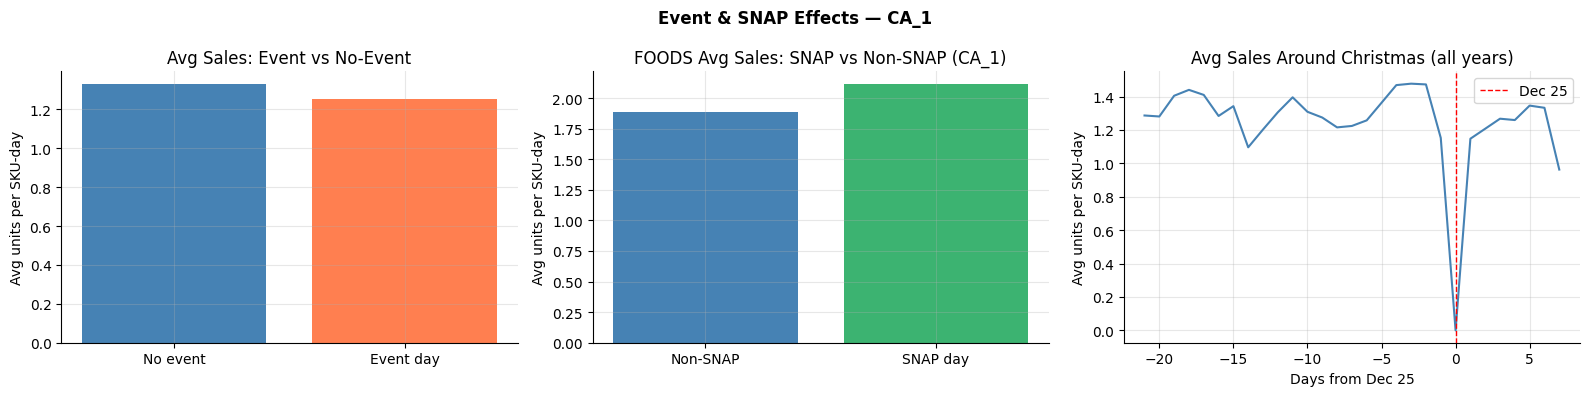

Top 10 events by avg daily sales:
event_name_1
OrthodoxEaster    1.698262
LaborDay          1.670056
SuperBowl         1.567672
Easter            1.482322
Mother's day      1.438668
Pesach End        1.424073
Father's day      1.420630
Eid al-Fitr       1.404854
ColumbusDay       1.377435
Purim End         1.365858


In [14]:
sample_long["has_event"] = sample_long["event_name_1"].notna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Event & SNAP Effects — {STORE}", fontweight="bold")

# ── 1. Event vs no-event ──────────────────────────────────────────────────────
event_avg = sample_long.groupby("has_event")["sales"].mean()
axes[0].bar(["No event", "Event day"],
            [event_avg[False], event_avg[True]],
            color=["steelblue", "coral"])
axes[0].set_title("Avg Sales: Event vs No-Event")
axes[0].set_ylabel("Avg units per SKU-day")

# ── 2. SNAP — FOODS category only ────────────────────────────────────────────
foods_long = sample_long[sample_long["cat_id"] == "FOODS"]
snap_avg = foods_long.groupby("snap_CA")["sales"].mean()
axes[1].bar(["Non-SNAP", "SNAP day"],
            [snap_avg.get(0, 0), snap_avg.get(1, 0)],
            color=["steelblue", "mediumseagreen"])
axes[1].set_title("FOODS Avg Sales: SNAP vs Non-SNAP (CA_1)")
axes[1].set_ylabel("Avg units per SKU-day")

# ── 3. Christmas window ───────────────────────────────────────────────────────
xmas_mask = (
    ((sample_long["date"].dt.month == 12) & (sample_long["date"].dt.day >= 4))
    | ((sample_long["date"].dt.month == 1)  & (sample_long["date"].dt.day <= 7))
)
xmas_window = sample_long[xmas_mask].copy()

def days_from_dec25(date):
    ref_year = date.year if date.month == 12 else date.year - 1
    return (date - pd.Timestamp(ref_year, 12, 25)).days

xmas_window["days_from_xmas"] = xmas_window["date"].map(days_from_dec25)
xmas_daily = xmas_window.groupby("days_from_xmas")["sales"].mean()
xmas_daily = xmas_daily[(xmas_daily.index >= -21) & (xmas_daily.index <= 7)]

axes[2].plot(xmas_daily.index, xmas_daily.values, color="steelblue", linewidth=1.5)
axes[2].axvline(0, color="red", linestyle="--", linewidth=1, label="Dec 25")
axes[2].set_title("Avg Sales Around Christmas (all years)")
axes[2].set_xlabel("Days from Dec 25")
axes[2].set_ylabel("Avg units per SKU-day")
axes[2].legend()

plt.tight_layout()
plt.savefig(PROCESSED / "fig_events_snap_xmas.png", dpi=100, bbox_inches="tight")
plt.show()

print("Top 10 events by avg daily sales:")
print(
    sample_long[sample_long["has_event"]]
    .groupby("event_name_1")["sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .to_string()
)

## 6  SKU Selection for Phase 2

We want 5 SKU-store combinations that together exercise the full modeling spectrum.

**Selection criteria (all from CA_1):**

| Slot | Pool | Rule | Count |
|---|---|---|---|
| FOODS continuous | zero_rate < 50% | top 2 by mean_daily | 2 |
| HOUSEHOLD continuous | zero_rate < 50% | top 1 by mean_daily | 1 |
| HOBBIES continuous | zero_rate < 50% | top 1 by mean_daily | 1 |
| Intermittent contrast | zero_rate > 70% | top 1 by mean_daily, prefer HOUSEHOLD or HOBBIES | 1 |

**Why this structure instead of a ranking-based approach:**  
A pure rank-by-volume shortlist collapses to FOODS (68 % of units) with HOBBIES as runner-up and HOUSEHOLD shut out entirely — which is what happened in the first pass. Guaranteeing one slot per category ensures Phase 2 forecasting models are evaluated against the full taxonomic range (grocery, household goods, hobbies/leisure), not just the easiest high-volume SKUs. FOODS gets two slots because it is both the dominant category and the one most affected by SNAP and event effects we want to model.

In [15]:
ca1_metrics = sku_metrics[sku_metrics["store_id"] == STORE].copy()

# Day-of-week std dev as a seasonality proxy
dow_std = (
    sample_long.groupby(["id", "weekday"])["sales"]
    .mean()
    .unstack()
    .std(axis=1)
    .rename("dow_std")
)
ca1_metrics = ca1_metrics.set_index("id").join(dow_std).reset_index()
ca1_metrics["seasonality_ratio"] = (
    ca1_metrics["dow_std"] / ca1_metrics["mean_daily"].clip(lower=0.01)
)

continuous_pool   = ca1_metrics[ca1_metrics["zero_rate"] < 0.50].copy()
intermittent_pool = ca1_metrics[ca1_metrics["zero_rate"] > 0.70].copy()

def top_n(pool, cat, n, sort_col="mean_daily"):
    return pool[pool["cat_id"] == cat].nlargest(n, sort_col)

shortlist = []

# ── FOODS: top 2 continuous ───────────────────────────────────────────────────
for rank, (_, row) in enumerate(top_n(continuous_pool, "FOODS", 2).iterrows(), 1):
    shortlist.append({
        "sku_store":  f"{row['item_id']}_{STORE}",
        "cat_id":     row["cat_id"],
        "zero_rate":  row["zero_rate"],
        "mean_daily": row["mean_daily"],
        "reason": (
            f"#{rank}-volume FOODS ({row['mean_daily']:.1f} u/day, "
            f"{row['zero_rate']:.0%} zero) — primary SARIMA/XGBoost candidate"
        ),
    })

# ── HOUSEHOLD: top 1 continuous ───────────────────────────────────────────────
for _, row in top_n(continuous_pool, "HOUSEHOLD", 1).iterrows():
    shortlist.append({
        "sku_store":  f"{row['item_id']}_{STORE}",
        "cat_id":     row["cat_id"],
        "zero_rate":  row["zero_rate"],
        "mean_daily": row["mean_daily"],
        "reason": (
            f"Top HOUSEHOLD by volume ({row['mean_daily']:.1f} u/day, "
            f"{row['zero_rate']:.0%} zero) — SARIMA/XGBoost candidate"
        ),
    })

# ── HOBBIES: top 1 continuous ─────────────────────────────────────────────────
for _, row in top_n(continuous_pool, "HOBBIES", 1).iterrows():
    shortlist.append({
        "sku_store":  f"{row['item_id']}_{STORE}",
        "cat_id":     row["cat_id"],
        "zero_rate":  row["zero_rate"],
        "mean_daily": row["mean_daily"],
        "reason": (
            f"Top HOBBIES by volume ({row['mean_daily']:.1f} u/day, "
            f"{row['zero_rate']:.0%} zero) — SARIMA/XGBoost candidate"
        ),
    })

# ── Intermittent contrast: prefer HOUSEHOLD or HOBBIES ───────────────────────
contrast = None
for cat in ["HOUSEHOLD", "HOBBIES", "FOODS"]:
    subset = top_n(intermittent_pool, cat, 1)
    if not subset.empty:
        contrast = subset.iloc[0]
        break

if contrast is not None:
    shortlist.append({
        "sku_store":  f"{contrast['item_id']}_{STORE}",
        "cat_id":     contrast["cat_id"],
        "zero_rate":  contrast["zero_rate"],
        "mean_daily": contrast["mean_daily"],
        "reason": (
            f"Intermittent {contrast['cat_id']} ({contrast['zero_rate']:.0%} zero days) "
            f"— Croston-method contrast case"
        ),
    })

# ── Print & save ──────────────────────────────────────────────────────────────
from collections import Counter
cat_counts = Counter(s["cat_id"] for s in shortlist)

print("=" * 70)
print(f"  PHASE 2 SKU SHORTLIST  ({STORE})")
print("=" * 70)
print(f"Total picks: {len(shortlist)}")
print("  " + " | ".join(f"{k}: {cat_counts[k]}" for k in sorted(cat_counts)))
for i, s in enumerate(shortlist, 1):
    print(f"\n{i}. {s['sku_store']}")
    print(f"   Category   : {s['cat_id']}")
    print(f"   Zero rate  : {s['zero_rate']:.1%}    Mean daily : {s['mean_daily']:.2f} u/day")
    print(f"   Rationale  : {s['reason']}")
print("\n" + "=" * 70)

pd.DataFrame(shortlist).to_parquet(PROCESSED / "eda_sku_shortlist.parquet", index=False)
print("Saved -> data/processed/eda_sku_shortlist.parquet")

  PHASE 2 SKU SHORTLIST  (CA_1)
Total picks: 5
  FOODS: 2 | HOBBIES: 1 | HOUSEHOLD: 2

1. FOODS_3_090_CA_1
   Category   : FOODS
   Zero rate  : 24.2%    Mean daily : 66.39 u/day
   Rationale  : #1-volume FOODS (66.4 u/day, 24% zero) — primary SARIMA/XGBoost candidate

2. FOODS_3_586_CA_1
   Category   : FOODS
   Zero rate  : 0.4%    Mean daily : 45.77 u/day
   Rationale  : #2-volume FOODS (45.8 u/day, 0% zero) — primary SARIMA/XGBoost candidate

3. HOUSEHOLD_1_118_CA_1
   Category   : HOUSEHOLD
   Zero rate  : 7.1%    Mean daily : 7.65 u/day
   Rationale  : Top HOUSEHOLD by volume (7.6 u/day, 7% zero) — SARIMA/XGBoost candidate

4. HOBBIES_1_348_CA_1
   Category   : HOBBIES
   Zero rate  : 20.6%    Mean daily : 11.85 u/day
   Rationale  : Top HOBBIES by volume (11.9 u/day, 21% zero) — SARIMA/XGBoost candidate

5. HOUSEHOLD_1_430_CA_1
   Category   : HOUSEHOLD
   Zero rate  : 78.3%    Mean daily : 1.17 u/day
   Rationale  : Intermittent HOUSEHOLD (78% zero days) — Croston-method contra